In [1]:
### Load in necessary libraries for data input and normalization
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# First, we get the data
dataset = pd.read_csv('IBM stock price.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [3]:
# train test split based on year
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

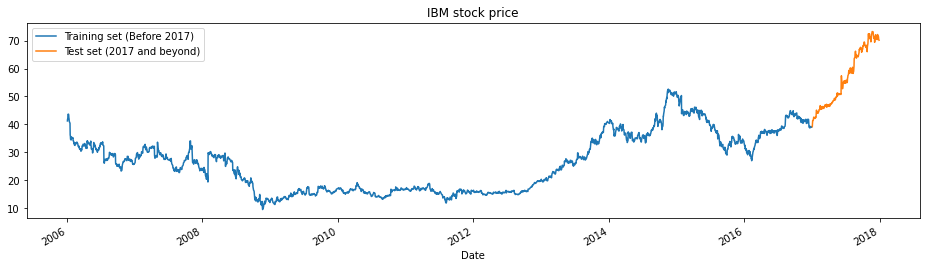

In [4]:
# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
test_set_scaled = sc.fit_transform(test_set)

In [6]:
def window_transform_series(series,window_size):
    # containers for input/output pairs
    X = []
    y = []
    for i in range(len(series)-window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    
        
    # reshape each 
    X = np.asarray(X)
    X.shape = (np.shape(X)[0:2])
    y = np.asarray(y)
    y.shape = (len(y),1)
    
    return X,y

In [7]:
# window the data using your windowing function
window_size = 7
X_train,y_train = window_transform_series(series=training_set_scaled, window_size=window_size)
X_test,y_test = window_transform_series(series=test_set_scaled, window_size=window_size)

In [14]:
# import keras network libraries
from keras.models import Sequential
from keras.layers import Dense, LSTM, SimpleRNN, Dropout

# build model using keras documentation recommended optimizer initialization

# The LSTM architecture
model2 = Sequential()
# First LSTM layer with Dropout regularisation
model2.add(LSTM(50, return_sequences=True, input_shape=(window_size,1)))
model2.add(Dropout(0.2))
# Second LSTM layer
# model2.add(LSTM(50, return_sequences=True))
# model2.add(Dropout(0.2))
# # Third LSTM layer
# model2.add(LSTM(units=50, return_sequences=True))
# model2.add(Dropout(0.2))
# Fourth LSTM layer
model2.add(LSTM(units=50))
model2.add(Dropout(0.2))
# The output layer
model2.add(Dense(units=1))

# Compiling the RNN
model2.compile(loss='mean_squared_error')

# Fitting to the training set
model2.fit(X_train,y_train,epochs=50,batch_size=32, verbose=2)

Epoch 1/50
87/87 - 4s - loss: 0.0090 - 4s/epoch - 50ms/step
Epoch 2/50
87/87 - 1s - loss: 0.0035 - 626ms/epoch - 7ms/step
Epoch 3/50
87/87 - 1s - loss: 0.0029 - 624ms/epoch - 7ms/step
Epoch 4/50
87/87 - 1s - loss: 0.0029 - 684ms/epoch - 8ms/step
Epoch 5/50
87/87 - 1s - loss: 0.0026 - 714ms/epoch - 8ms/step
Epoch 6/50
87/87 - 1s - loss: 0.0024 - 661ms/epoch - 8ms/step
Epoch 7/50
87/87 - 1s - loss: 0.0022 - 627ms/epoch - 7ms/step
Epoch 8/50
87/87 - 1s - loss: 0.0022 - 625ms/epoch - 7ms/step
Epoch 9/50
87/87 - 1s - loss: 0.0021 - 659ms/epoch - 8ms/step
Epoch 10/50
87/87 - 1s - loss: 0.0020 - 669ms/epoch - 8ms/step
Epoch 11/50
87/87 - 1s - loss: 0.0019 - 636ms/epoch - 7ms/step
Epoch 12/50
87/87 - 1s - loss: 0.0019 - 662ms/epoch - 8ms/step
Epoch 13/50
87/87 - 1s - loss: 0.0018 - 647ms/epoch - 7ms/step
Epoch 14/50
87/87 - 1s - loss: 0.0018 - 651ms/epoch - 7ms/step
Epoch 15/50
87/87 - 1s - loss: 0.0017 - 651ms/epoch - 7ms/step
Epoch 16/50
87/87 - 1s - loss: 0.0016 - 641ms/epoch - 7ms/step
Epo

In [15]:
# generate predictions for training
train_predict = model2.predict(X_train)
test_predict = model2.predict(X_test)

# print out training and testing errors
training_error = model2.evaluate(X_train, y_train, verbose=0)
print('training error = ' + str(training_error))

testing_error = model2.evaluate(X_test, y_test, verbose=0)
print('testing error = ' + str(testing_error))

training error = 0.00033399861422367394
testing error = 0.0006087649962864816


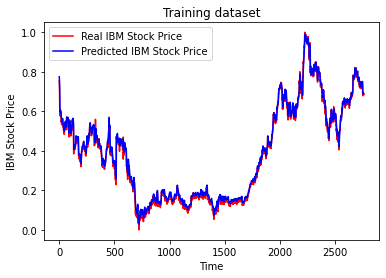

In [16]:
plt.plot(y_train, color='red',label='Real IBM Stock Price')
plt.plot(train_predict, color='blue',label='Predicted IBM Stock Price')
plt.title('Training dataset')
plt.xlabel('Time')
plt.ylabel('IBM Stock Price')
plt.legend()
plt.show()

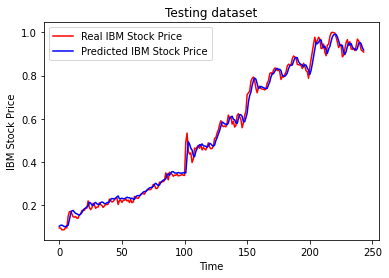

In [17]:
plt.plot(y_test, color='red',label='Real IBM Stock Price')
plt.plot(test_predict, color='blue',label='Predicted IBM Stock Price')
plt.title('Testing dataset')
plt.xlabel('Time')
plt.ylabel('IBM Stock Price')
plt.legend()
plt.show()